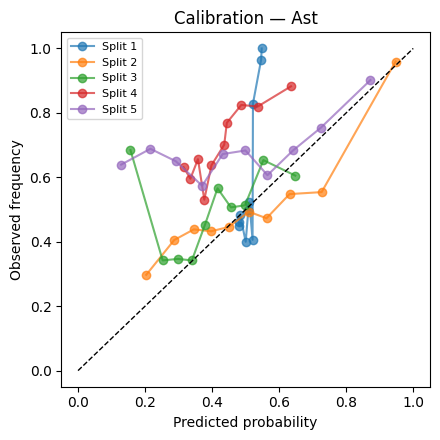

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots/calibration_Ast.png


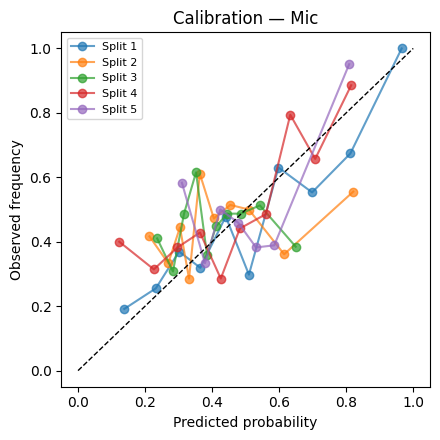

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots/calibration_Mic.png


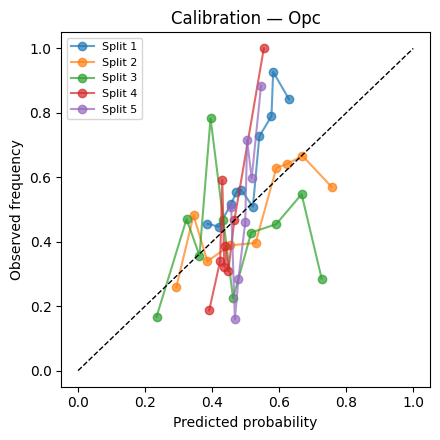

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots/calibration_Opc.png


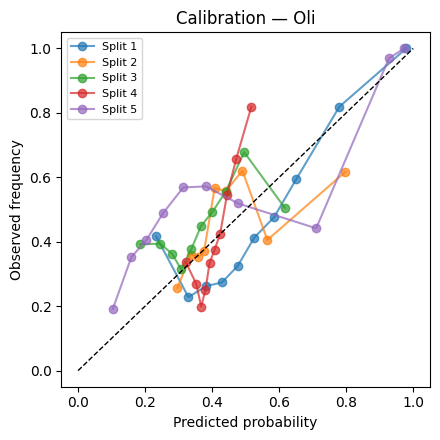

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots/calibration_Oli.png


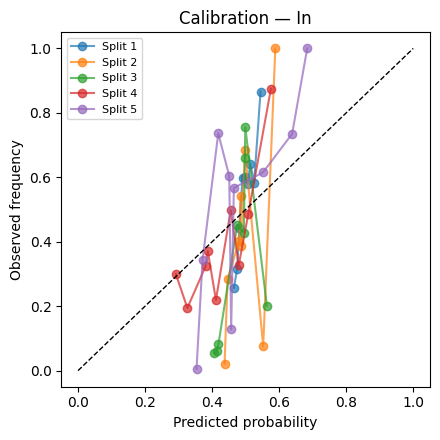

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots/calibration_In.png


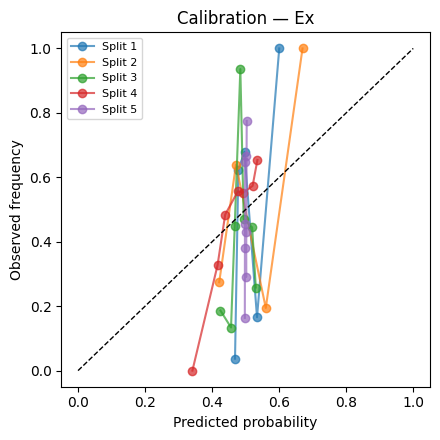

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots/calibration_Ex.png


In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

BASE_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_new"
CELL_TYPES = ["Ast", "Mic", "Opc", "Oli", "In", "Ex"]
SPLITS = [1, 2, 3, 4, 5]

OUT_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots"
os.makedirs(OUT_DIR, exist_ok=True)

for cell_type in CELL_TYPES:
    plt.figure(figsize=(4.5, 4.5))

    for split in SPLITS:
        pred_path = os.path.join(
            BASE_DIR, cell_type, f"split_{split}", "test_predictions.csv"
        )
        if not os.path.exists(pred_path):
            continue

        df = pd.read_csv(pred_path)

        prob_true, prob_pred = calibration_curve(
            df["true_label"],
            df["predicted_proba"],
            n_bins=10,
            strategy="quantile"
        )

        plt.plot(
            prob_pred,
            prob_true,
            marker="o",
            alpha=0.7,
            label=f"Split {split}"
        )

    plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration — {cell_type}")
    plt.legend(fontsize=8)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"calibration_{cell_type}.png")
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved: {out_path}")

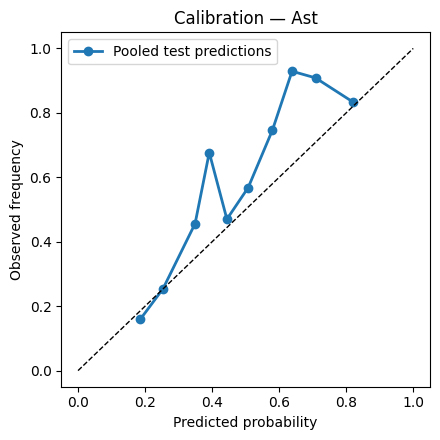

Saved pooled calibration plot: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled/calibration_Ast_pooled.png


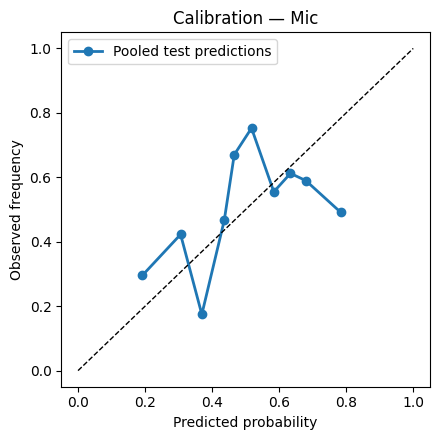

Saved pooled calibration plot: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled/calibration_Mic_pooled.png


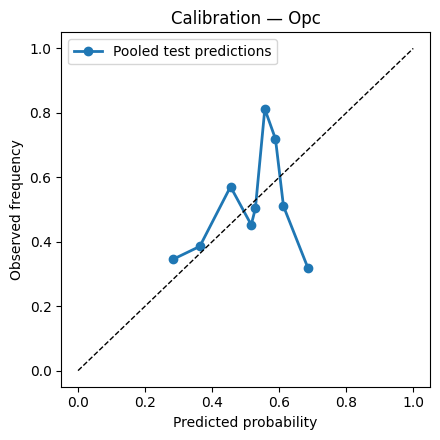

Saved pooled calibration plot: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled/calibration_Opc_pooled.png


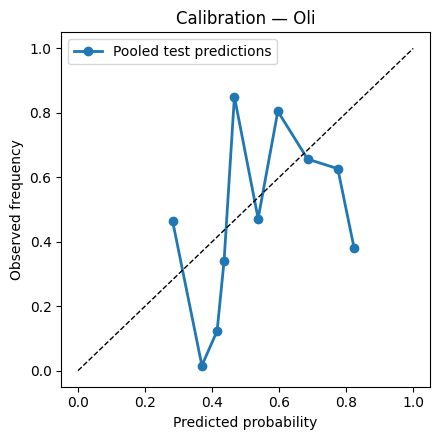

Saved pooled calibration plot: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled/calibration_Oli_pooled.png


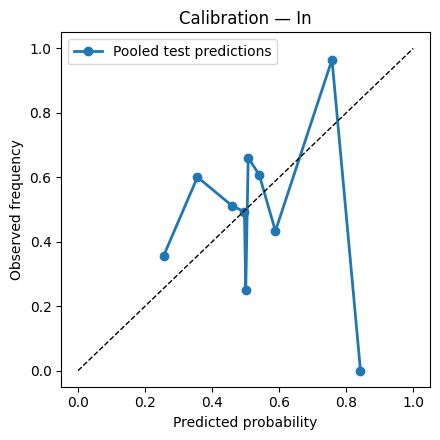

Saved pooled calibration plot: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled/calibration_In_pooled.png


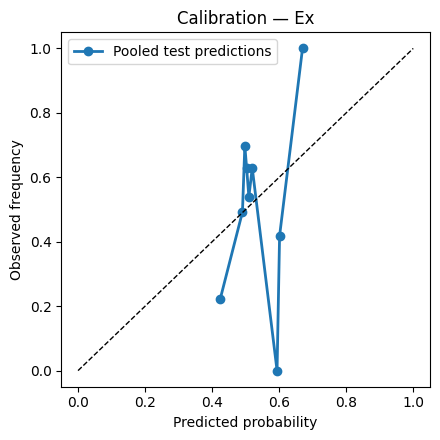

Saved pooled calibration plot: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled/calibration_Ex_pooled.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# ----------------------------
# CONFIG
# ----------------------------
BASE_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new"
CELL_TYPES = ["Ast", "Mic", "Opc", "Oli", "In", "Ex"]
SPLITS = [1, 2, 3, 4, 5]

OUT_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled"
os.makedirs(OUT_DIR, exist_ok=True)

N_BINS = 10   # standard choice for papers

# ----------------------------
# LOOP
# ----------------------------
for cell_type in CELL_TYPES:

    all_probs = []
    all_labels = []

    for split in SPLITS:
        pred_path = os.path.join(
            BASE_DIR, cell_type, f"split_{split}", "test_predictions.csv"
        )
        if not os.path.exists(pred_path):
            continue

        df = pd.read_csv(pred_path)

        all_probs.append(df["predicted_proba"].values)
        all_labels.append(df["true_label"].values)

    # Concatenate across splits
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)

    # Compute pooled calibration curve
    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=N_BINS,
        strategy="quantile"
    )

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(4.5, 4.5))

    plt.plot(
        mean_pred,
        frac_pos,
        marker="o",
        linewidth=2,
        label="Pooled test predictions"
    )

    plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)

    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration — {cell_type}")
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"calibration_{cell_type}_pooled.png")
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved pooled calibration plot: {out_path}")

In [14]:
import os
import pandas as pd
from sklearn.metrics import brier_score_loss

BASE_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new"
CELL_TYPES = ["Ast", "Mic", "Opc", "Oli", "In", "Ex"]
SPLITS = [1, 2, 3, 4, 5]

records = []

for cell_type in CELL_TYPES:
    for split in SPLITS:
        pred_path = os.path.join(
            BASE_DIR, cell_type, f"split_{split}", "test_predictions.csv"
        )
        if not os.path.exists(pred_path):
            continue

        df = pd.read_csv(pred_path)

        brier = brier_score_loss(
            df["true_label"],
            df["predicted_proba"]
        )

        records.append({
            "cell_type": cell_type,
            "split": split,
            "brier_score": brier
        })

brier_df = pd.DataFrame(records)

summary = (
    brier_df
    .groupby("cell_type")["brier_score"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print("\n=== BRIER SCORE SUMMARY ===")
print(summary)

summary.to_csv("brier_score_summary_by_cell_type.csv", index=False)


=== BRIER SCORE SUMMARY ===
  cell_type      mean       std       min       max
0       Ast  0.203978  0.068625  0.116452  0.299672
1        Ex  0.252962  0.018169  0.234541  0.283191
2        In  0.297567  0.112541  0.233448  0.498339
3       Mic  0.254519  0.022969  0.234203  0.285423
4       Oli  0.256335  0.069962  0.211380  0.379197
5       Opc  0.249831  0.023960  0.218521  0.282443


In [16]:

import os
import pandas as pd
from sklearn.metrics import brier_score_loss

BASE_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_new"
CELL_TYPES = ["Ast", "Mic", "Opc", "Oli", "In", "Ex"]
SPLITS = [1, 2, 3, 4, 5]

records = []

for cell_type in CELL_TYPES:
    for split in SPLITS:
        pred_path = os.path.join(
            BASE_DIR, cell_type, f"split_{split}", "test_predictions.csv"
        )
        if not os.path.exists(pred_path):
            continue

        df = pd.read_csv(pred_path)

        brier = brier_score_loss(
            df["true_label"],
            df["predicted_proba"]
        )

        records.append({
            "cell_type": cell_type,
            "split": split,
            "brier_score": brier
        })

brier_df = pd.DataFrame(records)

summary = (
    brier_df
    .groupby("cell_type")["brier_score"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print("\n=== BRIER SCORE SUMMARY ===")
print(summary)

summary.to_csv("brier_score_summary_by_cell_type.csv", index=False)


=== BRIER SCORE SUMMARY ===
  cell_type      mean       std       min       max
0       Ast  0.259329  0.023237  0.229425  0.282360
1        Ex  0.244048  0.008963  0.232160  0.254613
2        In  0.229755  0.015539  0.207525  0.245669
3       Mic  0.227657  0.035721  0.181281  0.262601
4       Oli  0.228430  0.017183  0.205792  0.253083
5       Opc  0.240013  0.012081  0.229488  0.259132


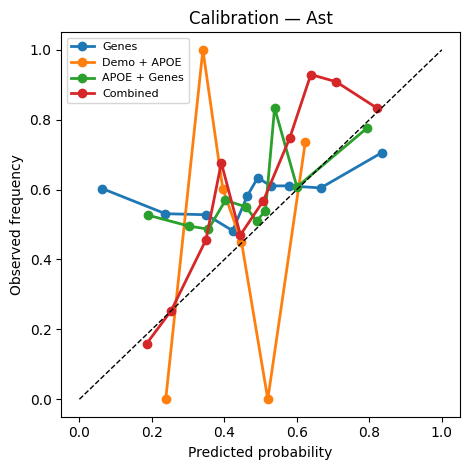

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models/calibration_Ast_pooled_models.png


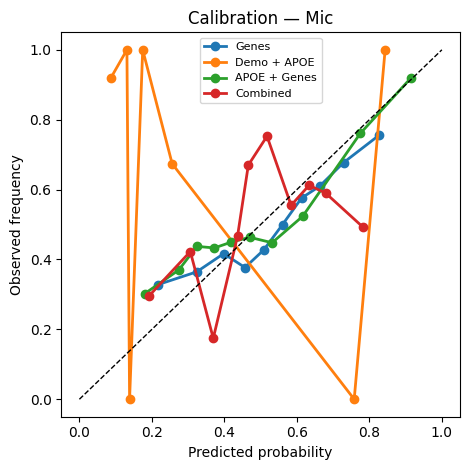

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models/calibration_Mic_pooled_models.png


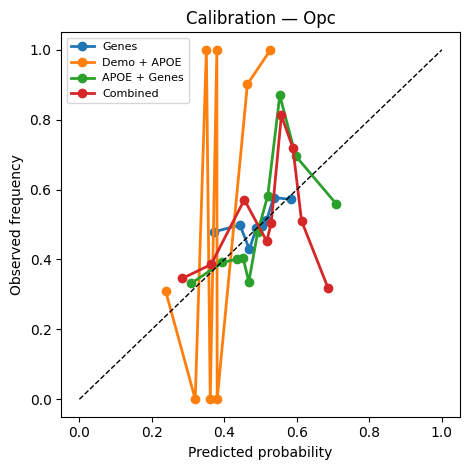

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models/calibration_Opc_pooled_models.png


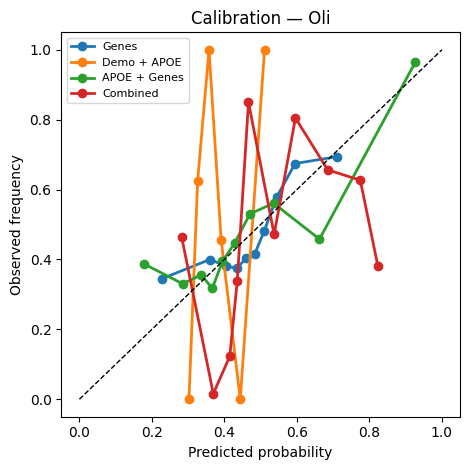

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models/calibration_Oli_pooled_models.png


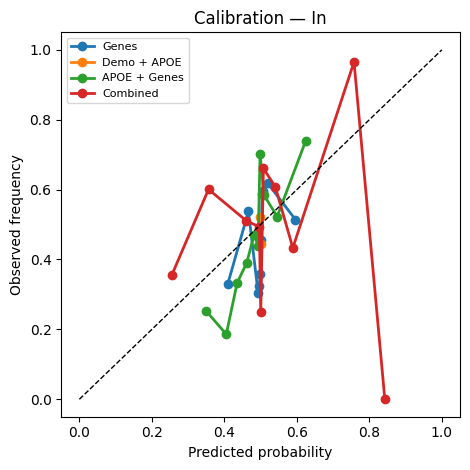

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models/calibration_In_pooled_models.png


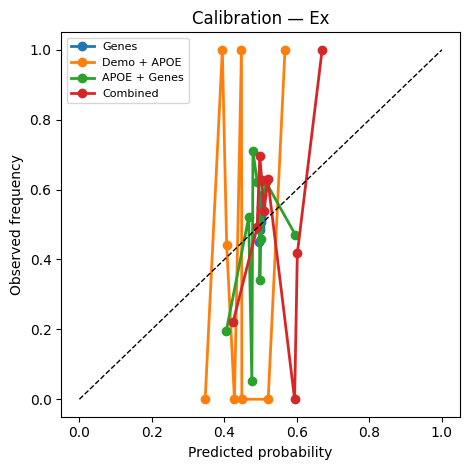

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models/calibration_Ex_pooled_models.png


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# ----------------------------
# CONFIG
# ----------------------------
CELL_TYPES = ["Ast", "Mic", "Opc", "Oli", "In", "Ex"]
SPLITS = [1, 2, 3, 4, 5]
N_BINS = 10

BASE_DIRS = {
    "Genes": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new",
    "Demo + APOE": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demo_new",
    "APOE + Genes": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_new",
    "Combined": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new",
}

OUT_DIR = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/calibration_plots_pooled_models"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# LOOP
# ----------------------------
for cell_type in CELL_TYPES:
    plt.figure(figsize=(4.8, 4.8))

    for model_name, base_dir in BASE_DIRS.items():
        all_probs = []
        all_labels = []

        for split in SPLITS:
            pred_path = os.path.join(
                base_dir, cell_type, f"split_{split}", "test_predictions.csv"
            )
            if not os.path.exists(pred_path):
                continue

            df = pd.read_csv(pred_path)
            all_probs.append(df["predicted_proba"].values)
            all_labels.append(df["true_label"].values)

        if len(all_probs) == 0:
            continue

        # Pool across splits
        y_prob = np.concatenate(all_probs)
        y_true = np.concatenate(all_labels)

        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=N_BINS,
            strategy="quantile"
        )

        plt.plot(
            mean_pred,
            frac_pos,
            marker="o",
            linewidth=2,
            label=model_name
        )

    # Perfect calibration reference
    plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)

    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration — {cell_type}")
    plt.legend(fontsize=8)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"calibration_{cell_type}_pooled_models.png")
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved: {out_path}")

In [20]:
import os
import pandas as pd
from sklearn.metrics import brier_score_loss

# ----------------------------
# CONFIG
# ----------------------------
CELL_TYPES = ["Ast", "Mic", "Opc", "Oli", "In", "Ex"]
SPLITS = [1, 2, 3, 4, 5]

BASE_DIRS = {
    "Genes": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new",
    "Demo + APOE": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demo_new",
    "APOE + Genes": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_new",
    "Combined": "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new",
}

records = []

# ----------------------------
# LOOP
# ----------------------------
for model_name, base_dir in BASE_DIRS.items():
    for cell_type in CELL_TYPES:
        for split in SPLITS:
            pred_path = os.path.join(
                base_dir, cell_type, f"split_{split}", "test_predictions.csv"
            )
            if not os.path.exists(pred_path):
                continue

            df = pd.read_csv(pred_path)

            brier = brier_score_loss(
                df["true_label"],
                df["predicted_proba"]
            )

            records.append({
                "model": model_name,
                "cell_type": cell_type,
                "split": split,
                "brier_score": brier
            })

brier_df = pd.DataFrame(records)

# ----------------------------
# SUMMARY
# ----------------------------
summary = (
    brier_df
    .groupby(["model", "cell_type"])["brier_score"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print("\n=== BRIER SCORE SUMMARY (POOLED OVER SPLITS) ===")
print(summary)

summary.to_csv(
    "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Tables/brier_scores_all_models_by_cell_type.csv",
    index=False
)


=== BRIER SCORE SUMMARY (POOLED OVER SPLITS) ===
           model cell_type      mean       std       min       max
0   APOE + Genes       Ast  0.259329  0.023237  0.229425  0.282360
1   APOE + Genes        Ex  0.244048  0.008963  0.232160  0.254613
2   APOE + Genes        In  0.229755  0.015539  0.207525  0.245669
3   APOE + Genes       Mic  0.227657  0.035721  0.181281  0.262601
4   APOE + Genes       Oli  0.228430  0.017183  0.205792  0.253083
5   APOE + Genes       Opc  0.240013  0.012081  0.229488  0.259132
6       Combined       Ast  0.203978  0.068625  0.116452  0.299672
7       Combined        Ex  0.252962  0.018169  0.234541  0.283191
8       Combined        In  0.297567  0.112541  0.233448  0.498339
9       Combined       Mic  0.254519  0.022969  0.234203  0.285423
10      Combined       Oli  0.256335  0.069962  0.211380  0.379197
11      Combined       Opc  0.249831  0.023960  0.218521  0.282443
12   Demo + APOE       Ast  0.242175  0.000000  0.242175  0.242175
13   Demo + 